<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/CINCIN_NEWTON_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

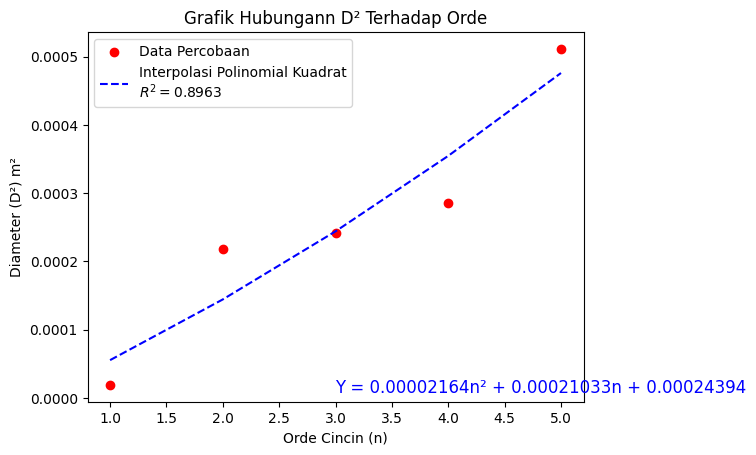

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
from sklearn.metrics import r2_score

# Data
D_squared = np.array([0.00001892, 0.00021786, 0.00024087, 0.00028493, 0.00051121])
n = np.array([1, 2, 3, 4, 5])

# Polynomial fitting (quadratic)
p = Polynomial.fit(n, D_squared, 2)

# Predicted values
D_squared_pred = p(n)

# Calculate R^2 value
r2 = r2_score(D_squared, D_squared_pred)

# Plotting
plt.scatter(n, D_squared, color='red', label='Data Percobaan')
plt.plot(n, D_squared_pred, 'b--', label=f'Interpolasi Polinomial Kuadrat\n$R^2 = {r2:.4f}$')
plt.title('Grafik Hubungann D² Terhadap Orde')
plt.xlabel('Orde Cincin (n)')
plt.ylabel('Diameter (D²) m²')

# Adding the regression function into the plot table
equation = f"Y = {p.coef[2]:.8f}n² + {p.coef[1]:.8f}n + {p.coef[0]:.8f}"
plt.text(3, 8e-6, equation, fontsize=12, color='blue')

# Adding the R² value in the legend
plt.legend(loc='best')

# Show the plot
plt.show()


Saving ANALISIS W5.xlsx to ANALISIS W5 (15).xlsx


--- Tabel Hasil Perhitungan ---


,x,M,H,Intensitas_Teoritis,M_Terfaktorkan,H_Terfaktorkan
0,0.0,0.020,NaN,1.000000,0.086957,NaN
1,0.1,0.030,NaN,0.996917,0.130435,NaN
2,0.2,0.030,NaN,0.951427,0.130435,NaN
3,0.3,0.050,NaN,0.770161,0.217391,NaN
4,0.4,0.130,NaN,0.397267,0.565217,NaN
5,0.5,0.130,NaN,0.032739,0.565217,NaN
6,0.6,0.080,NaN,0.173143,0.347826,NaN
7,0.7,0.150,NaN,0.834152,0.652174,NaN
8,0.8,0.130,NaN,0.838264,0.565217,NaN
9,0.9,0.080,NaN,0.044479,0.347826,NaN


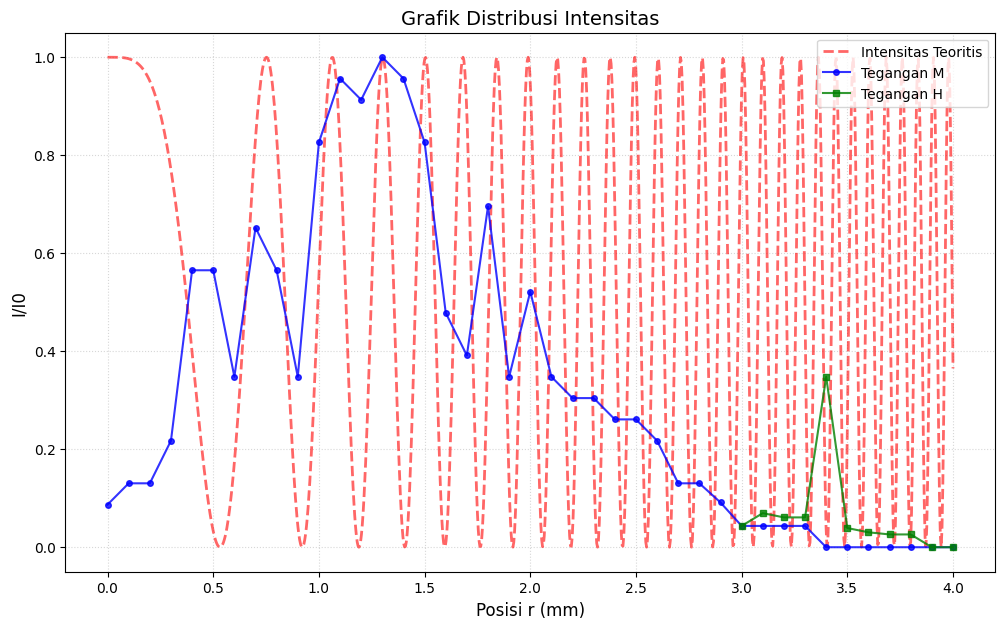

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display

print() # Pastikan terdapat 3 kolom yaitu x, M, H
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)

df.columns = [c.strip() for c in df.columns]

# Diketahui
lamda = 650e-9  # 650 nm ke meter
R = 0.87

if 'x' in df.columns and 'M' in df.columns and 'H' in df.columns:
    # --- PERHITUNGAN TEORITIS ---
    # r_m adalah posisi x dalam meter
    r_m = df['x'] * 1e-3
    df['Intensitas_Teoritis'] = np.cos((np.pi * r_m**2) / (lamda * R))**2

    # --- NORMALISASI TEGANGAN ---
    # Mencari nilai tegangan tertinggi dari kedua sisi (M dan H) untuk skala 0-1
    v_max = max(df['M'].max(), df['H'].max())
    df['M_Terfaktorkan'] = df['M'] / v_max
    df['H_Terfaktorkan'] = df['H'] / v_max

    print("\n" + "="*50)
    print("\n--- Tabel Hasil Perhitungan ---")
    print("="*50)
    display(HTML(df.to_html()))

    # Grafik
    plt.figure(figsize=(12, 7))

    # A. Plot Kurva Teoritis (Garis merah)
    x_smooth = np.linspace(df['x'].min(), df['x'].max(), 1000)
    r_smooth_m = x_smooth * 1e-3
    i_smooth = np.cos((np.pi * r_smooth_m**2) / (lamda * R))**2
    plt.plot(x_smooth, i_smooth, label='Intensitas Teoritis', color='red', linestyle='--', linewidth=2, alpha=0.6)

    # B. Plot Data M (Sisi Kanan)
    plt.plot(df['x'], df['M_Terfaktorkan'], label='Tegangan M', color='blue', marker='o', markersize=4, alpha=0.8)

    # C. Plot Data H (Sisi Kiri)
    plt.plot(df['x'], df['H_Terfaktorkan'], label='Tegangan H', color='green', marker='s', markersize=4, alpha=0.8)

    plt.title('Grafik Distribusi Intensitas', fontsize=14)
    plt.xlabel('Posisi r (mm)', fontsize=12)
    plt.ylabel('I/I0', fontsize=12)
    plt.grid(True, which='both', linestyle=':', alpha=0.5)
    plt.legend(loc='upper right')

    plt.show()

else:
    print(f"Error: Kolom tidak lengkap. Pastikan ada kolom 'x', 'M', dan 'H'.")
    print(f"Kolom yang terdeteksi: {list(df.columns)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00


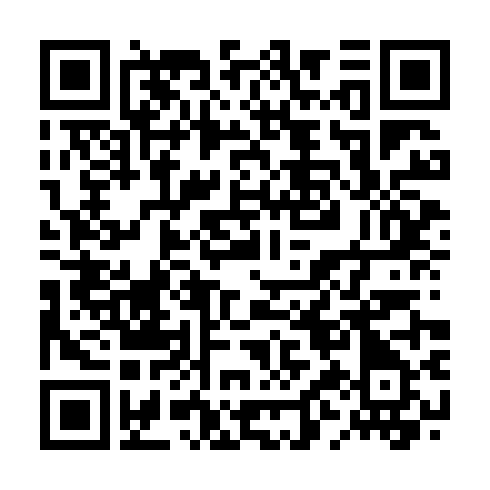

In [28]:
!pip install qrcode[pil]  # Install library qrcode
import qrcode

# Masukkan link Google Colab
colab_link = "https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/CINCIN_NEWTON_W5.ipynb"

# Buat QR code
qr = qrcode.make(colab_link)

# Simpan QR code sebagai gambar
qr.save("colab_qr.png")

# Tampilkan QR code
from IPython.display import display
display(qr)